In [753]:
%reload_ext autoreload
%autoreload 2
import phasecheck as pc
import sxmreader as sxm
import trackpy as tp
import matplotlib.pyplot as plt
from PIL import Image
from sxmreader import SXMReader
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from phasecheck import get_cffits


In [3]:
fs

,y,x,mass,size,ecc,orientation,angle,signal,raw_mass,ep,frame
1,1.087237,32.022617,1.446258,1.294327,0.208549,-2.663890,-2.663890,0.383177,-1.590022,0.089529,0
30,5.060858,3.105118,3.378495,1.187766,0.445584,2.838312,2.838312,0.595793,3.597915,0.050820,0
116,17.901108,148.212276,2.740647,1.198536,0.458732,-2.976203,-2.976203,0.467288,8.197524,0.036737,0
126,20.053719,180.806612,2.827095,1.244824,0.517031,2.909934,2.909934,0.464952,8.582635,0.035904,0
162,24.861731,161.752899,2.619152,1.232912,0.466312,3.018694,3.018694,0.408877,8.281944,0.036551,0
208,31.905047,135.857143,2.731301,1.219320,0.472022,2.897133,2.897133,0.446260,8.283594,0.036548,0
334,51.020364,13.152000,3.212608,1.200909,0.490453,-2.907979,-2.907979,0.558410,4.765065,0.046315,0
574,85.244300,9.763844,2.869151,1.224745,0.472863,3.088108,3.088108,0.464952,6.272673,0.041556,0
635,92.950198,183.843478,2.955599,1.252034,0.561709,-2.921695,-2.921695,0.476634,7.432857,0.038511,0
686,100.905365,38.224292,3.135505,1.161350,0.356979,-3.055732,-3.055732,0.553737,6.645985,0.040525,0


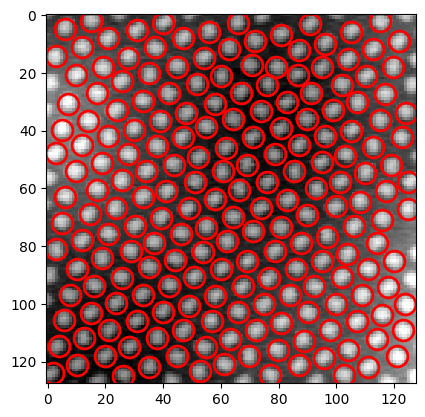

<AxesSubplot:>

In [703]:
#Getting data with SXM

path=['test_images/Image_668.sxm']
img = SXMReader(path, correct='lines')[0]
_kwargs={
    'diameter':5,
    'maxsize':200,
    'minmass':1,
    'separation':2,}
fs = tp.locate(img,**_kwargs) #gets data
tp.annotate(fs,img) #plots image with the red circles


/Users/lucnguyen/opt/anaconda3/envs/venv/lib/python3.7/site-packages/ipykernel_launcher.py:10: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  # Remove the CWD from sys.path while we load stuff.


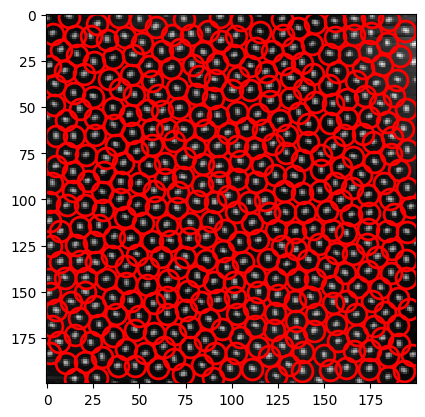

<AxesSubplot:>

In [3]:
#Getting data with jpg/png
path=['test_images/Image_924 Image Z (m).jpg']
_kwargs={
    'diameter':5,
    'maxsize':200,
    'minmass':1,
    'separation':2,}
img = Image.open(path[0])
#This part just to get img readable for trackpy
img = img.resize((200,200), Image.ANTIALIAS)
img=img.convert('L')
img.ndim=2
img.shape=img.size

fs=tp.locate(img,**_kwargs).reset_index()
tp.annotate(fs,img)


In [6]:
path=[f'test_images/Image_372.sxm']

xdim=SXMReader(path).scans[0].size['real']['x']*1e9 
ydim=SXMReader(path).scans[0].size['real']['y']*1e9
ydim

100.0

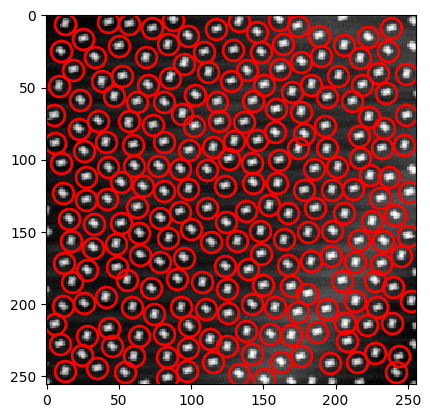

density=4.653061E+12
popt_constfunc (r2=1, rmse=0.55059): [-4.0586496]
popt_pwrlawdecay (r2=0.86634, rmse=0.51248): [-2.93359923  0.36064465]
popt_expdecay (r2=0.87395, rmse=0.51472): [-3.64851407 63.35371938]

winner: power law fit



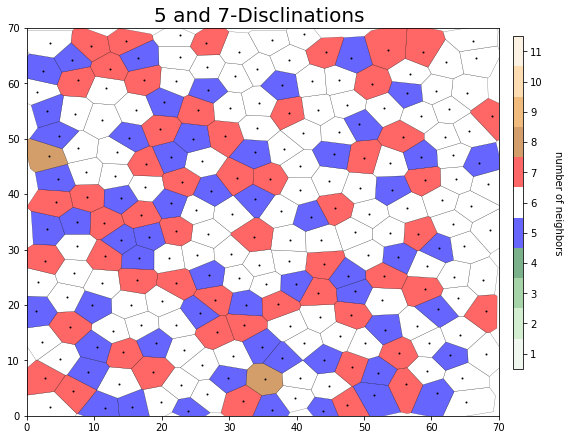

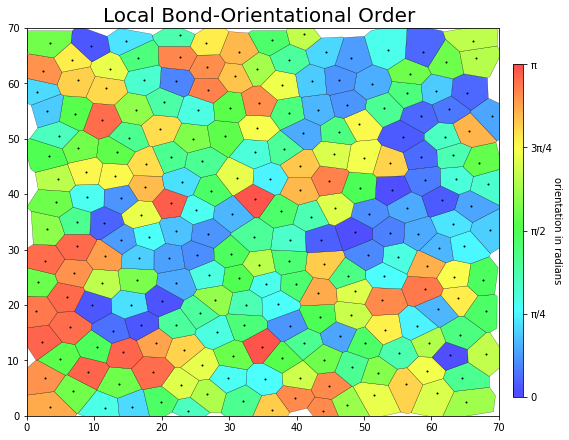

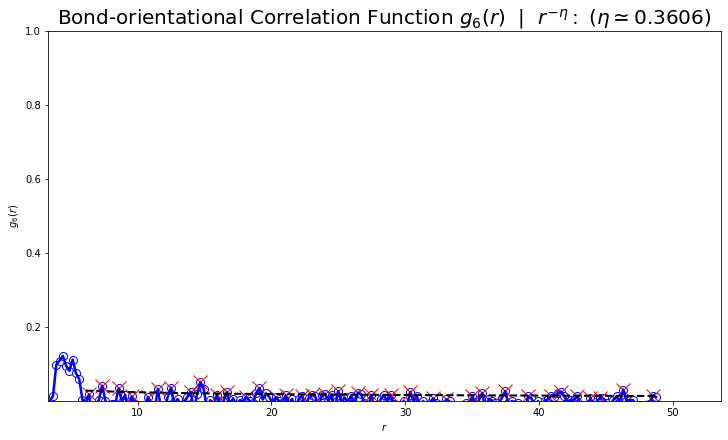

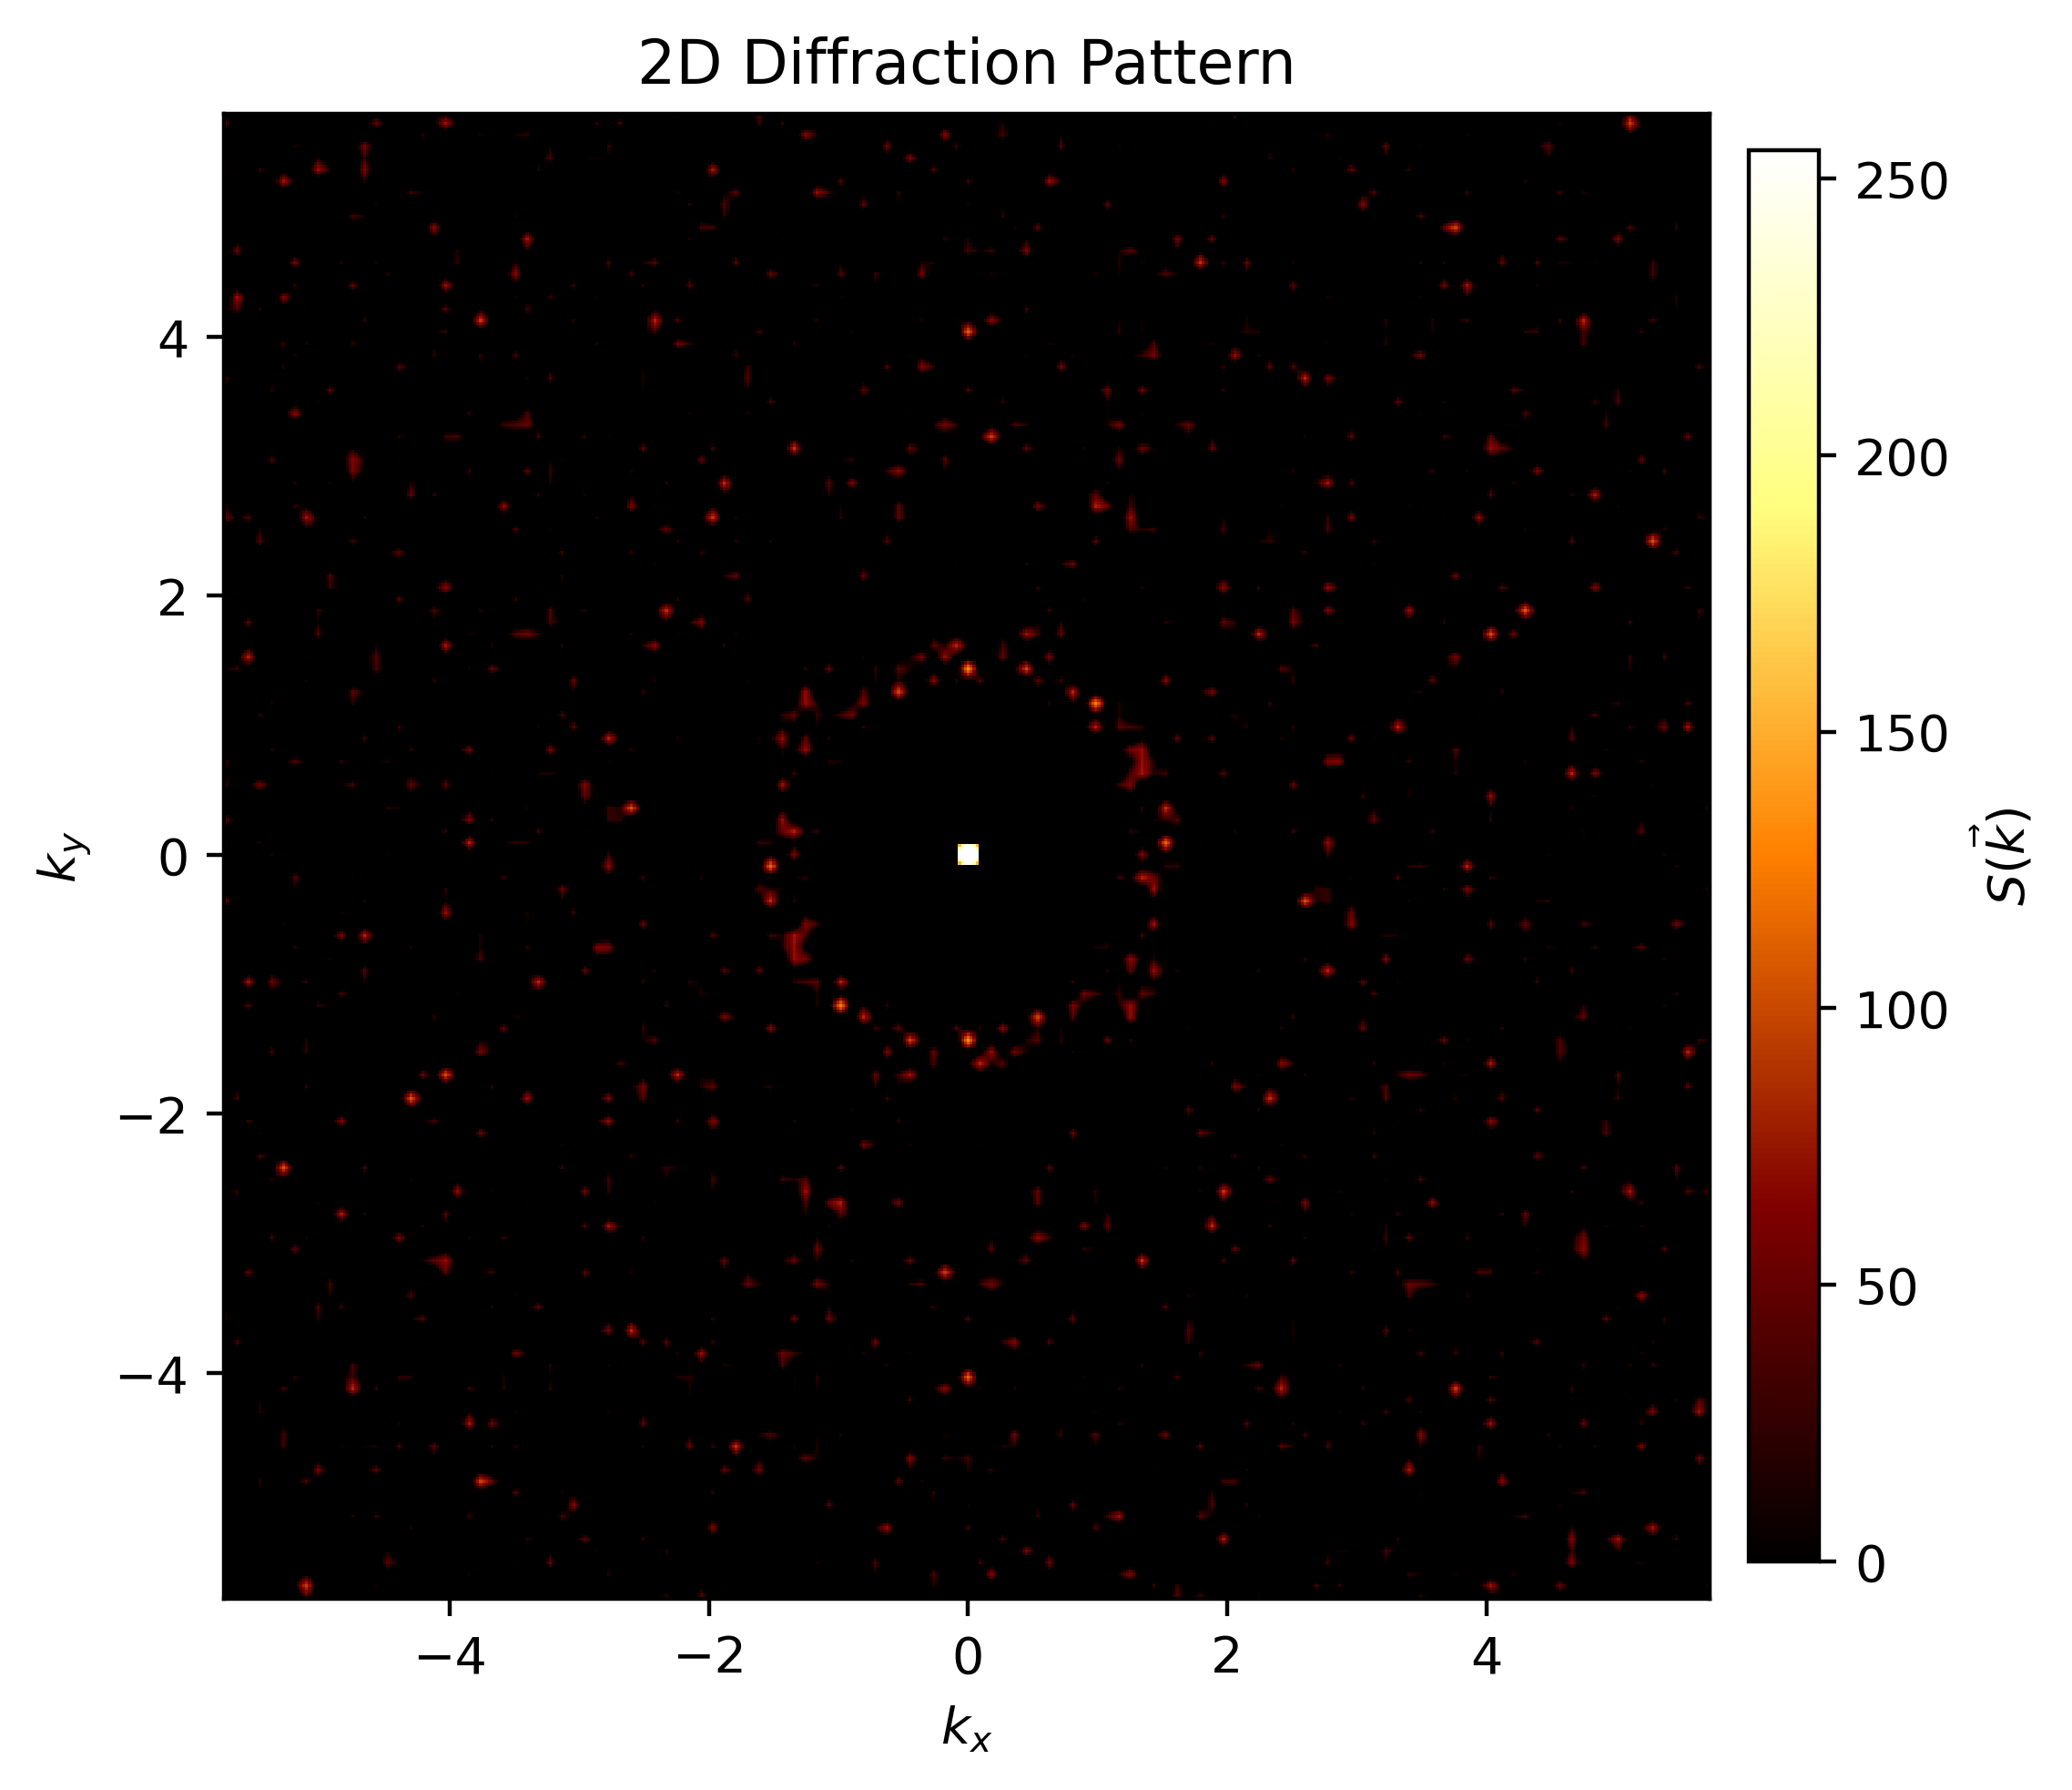

popt_constfunc (r2=1, rmse=0.7421): [-6.86542022]
popt_pwrlawdecay (r2=0.20275, rmse=0.33415): [-1.90510497  1.38298368]
popt_expdecay (r2=0.11933, rmse=0.25635): [-5.18377699 23.80684235]

winner: exponential fit



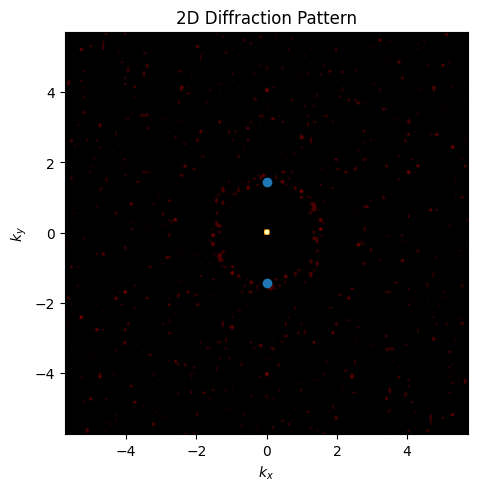

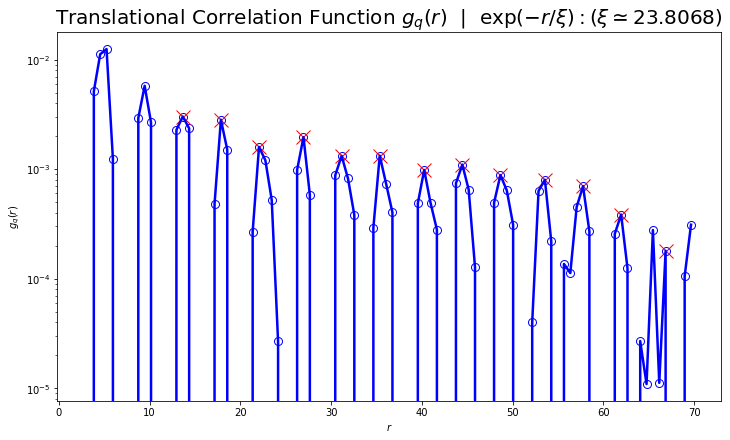

In [756]:
#The two cells above are esentially done when initializing a 
#phasecheck.imgdata instance

_kwargs={
    'diameter':7,
    'maxsize':300,
    'minmass':1,
    'separation':7
    
    ,}

path=[f'test_images/Image_107.sxm']
img_d=pc.imgdata(path,filetype='SXM',**_kwargs)
tp.annotate(img_d.data,img_d.img)
#SXM files have scan dimensions in meters
xdim=SXMReader(path).scans[0].size['real']['x']*100 
ydim=SXMReader(path).scans[0].size['real']['y']*100

density=img_d.data.shape[0]/(xdim*ydim) #calculate density
print(f'density={density:E}')

#plots Voronoi diagram, kind=0 for nearest neighbor
pc.plot_boops(img_d,kind=0,realdim=True) 

#kind=1 for orientation
pc.plot_boops(img_d,kind=1,realdim=True) 

#start and dist choose starting point and distance between peaks,
#fit_id=None for best fit, 0,1,2 to choose what curve

#orientational order l
pc.plot_bocf(img_d,start=2,fit_id=None,realdim=True,dist=3,bins=200,ytype='linear',xtype='linear',ylim=(1e-10,1))

#pc.plot_rdf(img_d,start=1,fit_id=None)


#structure factor
pc.plot_ssf2(img_d,upper=0.2,lower=0.01,grid_size=512,dpi=400,realdim=True)

vector=pc.find_recip_vector(img_d,0.1,tolerance=1,grid_size=512,realdim=True)
pc.plot_tocf(img_d,vector[0],fit_id=None,bins=100,realdim=True,start=2,p_dist=6,ytype='log',xtype='linear')


In [279]:
find_peaks()

<function scipy.signal._peak_finding.find_peaks(x, height=None, threshold=None, distance=None, prominence=None, width=None, wlen=None, rel_height=0.5, plateau_size=None)>

popt_constfunc (r2=1, rmse=0.40987): [5.67485377]
popt_pwrlawdecay (r2=0.72463, rmse=0.3489): [7.26399762 0.44429314]
popt_expdecay (r2=0.51914, rmse=0.29532): [ 6.34368185 59.44726469]

winner: exponential fit



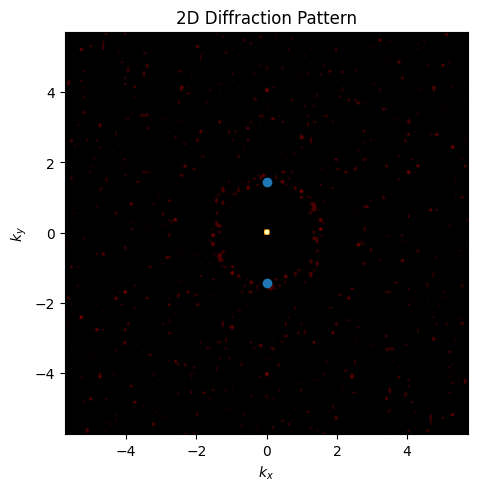

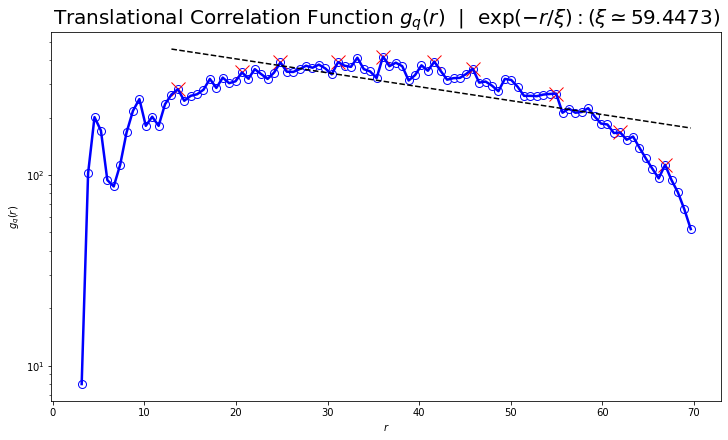

In [437]:
def find_recip_vector(img_d,radius,tolerance=100,realdim=False,grid_size=512,lower=0.01,upper=1):
    if realdim==False:
        xdim, ydim = img_d.img.shape
        xscale=1
        yscale=1
    else:
        if img_d.sxm==True:
            xdim=img_d.dims[0]
            ydim=img_d.dims[1]
        else:
            xdim=realdim[0]
            ydim=realdim[1]
        xscale=xdim/img_d.img.shape[0]
        yscale=ydim/img_d.img.shape[1]
    xydata=np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale] for i in range(img_d.data['x'].size)  ])
    points =np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale,0] for i in range(img_d.data['x'].size)  ])
    points=points-points[1]
    box3d = freud.Box.cube(L=xdim) 
    ssf =  freud.diffraction.DiffractionPattern(grid_size=grid_size)
    ssf.compute(system=(box3d, points))
    ssfmin, ssfmax = np.min(ssf.k_values), np.max(ssf.k_values)

    data=ssf.diffraction
# Define the center coordinates
    center_x = data.shape[0] // 2
    center_y = data.shape[1] // 2

# Define the radius of the center circle
    center_radius = radius/ssfmax*(grid_size/2)  # Adjust this value as needed

# Create a grid of distances from the center
    x, y = np.ogrid[:data.shape[0], :data.shape[1]]
    distances = np.sqrt((x - center_x)**2 + (y - center_y)**2)

# Create a circular mask to exclude the center region
    mask = distances <= center_radius

# Apply the mask to the array and find the maximum value
    max_value = np.max(data[~mask])
    peaks=(np.argwhere(np.abs(data-max_value)<tolerance)-(center_y,center_x))*ssfmax/(grid_size/2)
    peaks=peaks[:,::-1]
    peaks=peaks[np.sqrt((peaks[:,0]**2+peaks[:,1]**2))>radius]
    extent=[ssfmin, ssfmax, ssfmin, ssfmax]
    ssf_vals=ssf.to_image(cmap='afmhot',vmin=lower*ssf.N_points,vmax=upper*ssf.N_points)
    
    fig, ax = plt.subplots(1, 1, facecolor='w', constrained_layout=True,)
    sfax = ax.imshow(ssf_vals, origin='lower', cmap='afmhot', extent=[ssfmin, ssfmax, ssfmin, ssfmax])
    ax.set(xlabel=r'$k_{x}$', ylabel=r'$k_{y}$', title=r'2D Diffraction Pattern')
    ax.scatter(peaks[:,0],peaks[:,1])
    return peaks,ssf,fig


def plot_tocf_(img_d,g, bins=100,realdim=False, fit_id=None,
 p_dist=1,dpi=72,savename=False,filetype='svg',xtype='linear',
               ytype='log',start=1,r2fit=1):
    if realdim==False:
        xdim, ydim = img_d.img.shape
        xscale=1
        yscale=1
    else:
        if img_d.sxm==True:
            xdim=img_d.dims[0]
            ydim=img_d.dims[1]
        else:
            xdim=realdim[0]
            ydim=realdim[1]
        xscale=xdim/img_d.img.shape[0]
        yscale=ydim/img_d.img.shape[1]

     
    points=np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale] for i in range(img_d.data['x'].size)  ])
    points=points-points[1]
    rmax=xdim

    bin_size=rmax/bins
    n = points.shape[0]
    pairwise_distances = []
    pairs = []
    
    for (i, j) in itertools.combinations(range(n), 2):
        dist = np.linalg.norm(points[i] - points[j])
        pairwise_distances.append(dist)
        pairs.append((i, j))   
    bins = defaultdict(list)    
    for dist, pair in zip(pairwise_distances, pairs):
        if dist <= rmax:
            bin_index = math.ceil(dist / bin_size)
            bins[bin_index].append(pair)
    torders=[]
    rs=[]
    for bin_index in sorted(bins.keys()):
        r=bin_index*bin_size-bin_size/2
        rs.append(r)
        prefactor=1/(2*np.pi*bin_size*r)
        terms=[]
        for pair in bins[bin_index]:
            terms.append(np.exp(1j*np.dot(g,points[pair[0]]-points[pair[1]])))
        torders.append(prefactor*np.array(terms).sum()/len(terms)) 
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', constrained_layout=True, dpi=dpi)
    rs=np.array(rs)
    torders=np.real(torders)
    ax.plot(rs, torders, 'o', ms=8, c='w', mec='b', zorder=2)
    ax.plot(rs, torders, lw=2.5, c='b', zorder=3)
    cfpks = find_peaks(torders,distance=p_dist,height=1e-10)[0]
    idxlim = np.argwhere(rs == rs[cfpks][start])[0][0]-1
    ax.plot(rs[cfpks[start:]], torders[cfpks[start:]], 'x', c='r', ms=14)
    
    fit_func, popt, fit_text = get_cffits(
        rs[cfpks[start:]],
        torders[cfpks[start:]], fit_id,r2fit=r2fit,)
    ax.plot(rs[idxlim:],np.exp(fit_func(rs[idxlim:], *popt)), '--', lw=1.5, c='k', zorder=9)
    #ax.plot(rs,np.exp(fit_func(rs), *popt), '--', lw=1.5, c='k', zorder=9)

    ax.set(xlabel=r'$r$', ylabel=f'$g_{{q}}(r)$', title=f'Translational Correlation Function $g_{{q}}(r)$  |  {fit_text}')
    ax.set_title(label=f'Translational Correlation Function $g_{{q}}(r)$  |  {fit_text}',
                fontsize=20)
    ax.set(xscale=xtype)
    ax.set(yscale=ytype)
    if savename!=False:
        fig.savefig(savename, format=filetype)
vector,ssf,plot=find_recip_vector(img_d,0.1,tolerance=1,grid_size=512,realdim=True)
plot_tocf_(img_d,vector[0],fit_id=None,bins=100,realdim=True,start=2,p_dist=6,ytype='log',xtype='linear')

In [319]:
cfpks

array([10, 58])

In [322]:
find_peaks(torders,distance=None)[0]

array([ 5, 10, 12, 14, 17, 20, 26, 31, 33, 37, 41, 43, 45, 47, 51, 53, 56,
       58, 63, 67, 70, 72, 75, 78, 81])

In [244]:
vector[0]

array([-2.50345665, -2.37828381])

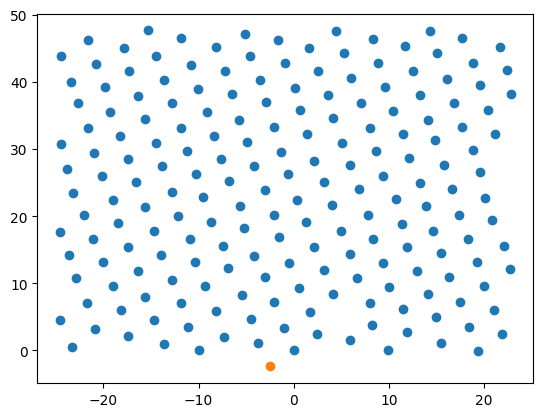

In [243]:
plt.scatter(points[:,0],points[:,1])
plt.scatter(vector[0][0],vector[0][1])

In [ ]:
kk

In [375]:
np.arccos(-0.06/np.linalg.norm(xydata[5])/np.linalg.norm(vector[12]))*360/(2*np.pi)

90.45754563280845

In [13]:
xydata=xydata-xydata[0]
i=10
plt.scatter(xydata[:,0],xydata[:,1])
plt.scatter(xydata[i,0],xydata[i,1])

plt.scatter(vector[12][0],vector[12][1])
(np.dot(xydata[i],vector[12]))

NameError: name 'xydata' is not defined

In [304]:
xscale=50/128
yscale=50/128
points=np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale,0] for i in range(img_d.data['x'].size)  ])


In [298]:
vector[0]

array([-2.37828381, -2.50345665])

In [384]:
    
    
xydata=np.array([[img_d.data['x'][i]*50/128,img_d.data['y'][i]*50/128] for i in range(img_d.data['x'].size)  ])
points =np.array([[img_d.data['x'][i]*50/128,img_d.data['y'][i]*50/128,0] for i in range(img_d.data['x'].size)  ])

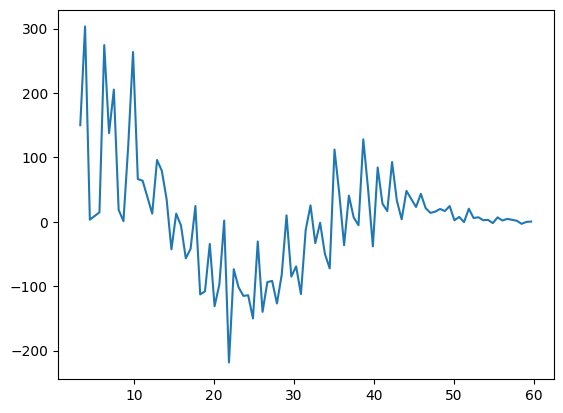

In [15]:
g=vector[0]
import numpy as np
import itertools
from collections import defaultdict
rmax=60
bins=100
bin_size=rmax/bins
for q in range(1):
    n = points.shape[0]
    pairwise_distances = []
    pairs = []
    
    for (i, j) in itertools.combinations(range(n), 2):
        dist = np.linalg.norm(points[i] - points[j])
        pairwise_distances.append(dist)
        pairs.append((i, j))   
    bins = defaultdict(list)    
    for dist, pair in zip(pairwise_distances, pairs):
        if dist <= rmax:
            bin_index = math.ceil(dist / bin_size)
            bins[bin_index].append(pair)
    torders=[]
    rs=[]
for bin_index in sorted(bins.keys()):
    r=bin_index*bin_size-bin_size/2
    rs.append(r)
    prefactor=1/(2*np.pi*bin_size*r)
    terms=[]
    for pair in bins[bin_index]:
        terms.append(np.exp(1j*np.dot(g,points[pair[0]]-points[pair[1]])))
    torders.append(np.array(terms).sum())
plt.plot(rs,np.real(torders))    

In [302]:
points

array([[-9.91483127e+00,  4.67436809e-03],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 9.89016803e+00,  1.35831707e-01],
       [ 1.93600485e+01, -4.66613992e-02],
       [-2.32479839e+01,  5.55861527e-01],
       [-1.35893555e+01,  1.00134149e+00],
       [-3.78546919e+00,  1.05521604e+00],
       [ 1.54472199e+01,  1.14784395e+00],
       [ 5.94802307e+00,  1.55726262e+00],
       [-1.74420267e+01,  2.12715112e+00],
       [-7.27996883e+00,  2.05535295e+00],
       [ 2.42800259e+00,  2.45823914e+00],
       [ 2.18626042e+01,  2.51002135e+00],
       [ 1.19247718e+01,  2.70218109e+00],
       [-2.08899636e+01,  3.26606898e+00],
       [-1.11047876e+01,  3.45792779e+00],
       [-1.03597592e+00,  3.32582520e+00],
       [ 8.28126542e+00,  3.80151953e+00],
       [ 1.83765812e+01,  3.54172549e+00],
       [-2.45692157e+01,  4.52931678e+00],
       [-1.47024712e+01,  4.47304450e+00],
       [-4.47673652e+00,  4.72298190e+00],
       [ 1.49693576e+01,  4.94763923e+00],
       [ 1.

In [232]:
idxlim = np.argwhere(rs == rs[cfpks][start])[0][0]-1


TypeError: only integer scalar arrays can be converted to a scalar index

In [234]:
rs[cfpks][start]

NameError: name 'start' is not defined

In [263]:
plt.plot()

100.0

In [278]:
img_d.data['x'].max()

124.09493935591803

In [38]:

X.flatten()

array([  0. ,   0.5,   1. , ...,  99. ,  99.5, 100. ])

In [43]:
[(xx[i],yy[i]) for i in range(np.size(xx))]

NameError: name 'xx' is not defined

In [87]:
np.dot(points[:,:2,],vector[0]/(2*np.pi))

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  -0.90553977,  -0.90553977,  -0.90553977,
        -0.90553977,  -0.90553977,  -0.90553977,  -0.90553977,
        -0.90553977,  -0.90553977,  -0.90553977,  -0.90553977,
        -0.90553977,  -0.90553977,  -0.90553977,  -0.90553977,
        -0.90553977,  -0.90553977,  -0.90553977,  -0.90553977,
        -0.90553977,  -0.90553977,  -1.81107955,  -1.81107955,
        -1.81107955,  -1.81107955,  -1.81107955,  -1.81107955,
        -1.81107955,  -1.81107955,  -1.81107955,  -1.81107955,
        -1.81107955,  -1.81107955,  -1.81107955,  -1.81107955,
        -1.81107955,  -1.81107955,  -1.81107955,  -1.81107955,
        -1.81107955,  -1.81107955,  -1.81107955,  -2.71

In [ ]:
points

In [73]:
points

array([[  0.,   0.,   0.],
       [  5.,   0.,   0.],
       [ 10.,   0.,   0.],
       ...,
       [ 90., 100.,   0.],
       [ 95., 100.,   0.],
       [100., 100.,   0.]])

In [76]:
vector

array([], shape=(0, 2), dtype=float64)

In [86]:
vector[0]

array([ 0.        , -1.25172832])

In [223]:
x=np.linspace(0,100,21)
y=np.linspace(0,100,23)
X,Y=np.meshgrid(x,y)
xx=X.flatten()
yy=Y.flatten()
points=np.array([(xx[i],yy[i],0) for i in range(np.size(xx))])
vector=find_recip_vector(points,0.01,tolerance=1)[0]

IndexError: boolean index did not match indexed array along dimension 1; dimension is 1 but corresponding boolean dimension is 512

In [119]:
peak_y=y[np.where([(max_value-data)<tolerance])[1]]


IndexError: index 256 is out of bounds for axis 0 with size 1

In [147]:
np.where((max_value-data)<tolerance)

(array([256, 256, 256]), array([180, 256, 332]))

In [152]:
y.T[332]

array([332])

In [132]:
y.T[np.where((max_value-data)<tolerance)[1]]

array([[180],
       [256],
       [332]])

In [143]:
peak_y

array([[256],
       [256],
       [256]])

In [141]:
np.hstack((peak_x,peak_y))

array([[  0, 256],
       [  0, 256],
       [  0, 256]])

In [160]:
np.shape(data)

(512, 512)

In [161]:
np.argwhere((max_value-data)<tolerance)

array([[256, 180],
       [256, 256],
       [256, 332]])

In [208]:
peaks[:,::-1]

array([[-1.25172832, -1.3834892 ],
       [ 0.        , -1.3834892 ],
       [ 1.25172832, -1.3834892 ],
       [-2.50345665,  0.        ],
       [-1.25172832,  0.        ],
       [ 0.        ,  0.        ],
       [ 1.25172832,  0.        ],
       [ 2.50345665,  0.        ],
       [-1.25172832,  1.3834892 ],
       [ 0.        ,  1.3834892 ],
       [ 1.25172832,  1.3834892 ]])

In [209]:
peaks

array([[-1.3834892 , -1.25172832],
       [-1.3834892 ,  0.        ],
       [-1.3834892 ,  1.25172832],
       [ 0.        , -2.50345665],
       [ 0.        , -1.25172832],
       [ 0.        ,  0.        ],
       [ 0.        ,  1.25172832],
       [ 0.        ,  2.50345665],
       [ 1.3834892 , -1.25172832],
       [ 1.3834892 ,  0.        ],
       [ 1.3834892 ,  1.25172832]])

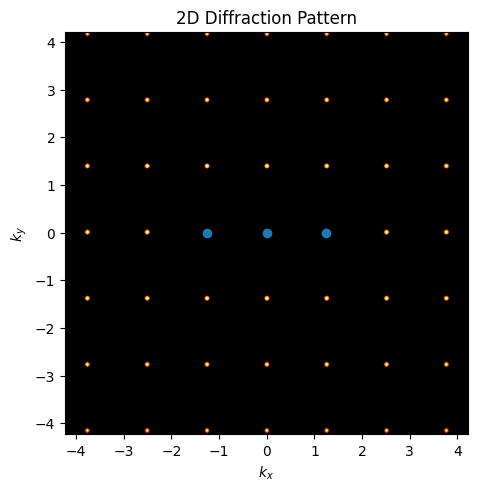

In [220]:
grid_size=512
radius=0.001
tolerance=10
lower=0.1
upper=1
for q3 in range(1):
    box3d = freud.Box.cube(L=np.max(points[:,0])) 
    points=points-points[1]

    ssf =  freud.diffraction.DiffractionPattern(grid_size=grid_size)
    ssf.compute(system=(box3d, points))
    ssfmin, ssfmax = np.min(ssf.k_values), np.max(ssf.k_values)

    data=ssf.diffraction
# Define the center coordinates
    center_x = data.shape[0] // 2
    center_y = data.shape[1] // 2

# Define the radius of the center circle
    center_radius = radius/ssfmax*(grid_size/2)  # Adjust this value as needed

# Create a grid of distances from the center
    x, y = np.ogrid[:data.shape[0], :data.shape[1]]
    distances = np.sqrt((x - center_x)**2 + (y - center_y)**2)

# Create a circular mask to exclude the center region
    mask = distances <= center_radius

# Apply the mask to the array and find the maximum value
    max_value = np.max(data[~mask])
    peaks=(np.argwhere(np.abs(data-max_value)<tolerance)-(center_y,center_x))*ssfmax/(grid_size/2)
    peaks=peaks[:,::-1]
    extent=[ssfmin, ssfmax, ssfmin, ssfmax]
    ssf_vals=ssf.to_image(cmap='afmhot',vmin=lower*ssf.N_points,vmax=upper*ssf.N_points)
    
    fig, ax = plt.subplots(1, 1, facecolor='w', constrained_layout=True,)
    sfax = ax.imshow(ssf_vals, origin='lower', cmap='afmhot', extent=[ssfmin, ssfmax, ssfmin, ssfmax])
    ax.set(xlabel=r'$k_{x}$', ylabel=r'$k_{y}$', title=r'2D Diffraction Pattern')
    ax.scatter(peaks[:,0],peaks[:,1])
    #return peaks.T,ssf,fig


In [73]:
def add_lattice(lattice,theta=0,point=(1,0),size=10,plotonly=True):
        s=lattice/np.sqrt(3)
        coord=np.arange(-size/2,size/2,lattice*np.sqrt(3))
        coord=coord-coord[int(np.size(coord)/2)]+point[0]-s/2
        coord2=np.arange(-size/2,size/2,lattice)
        coord2=coord2-coord2[int(np.size(coord2)/2)]+point[1]
        
        X,Y=np.meshgrid(coord,coord2)
        x,y=X.flatten(),Y.flatten()
        x2=x+lattice*np.sqrt(3)/2
        y2=y+lattice/2
        x=np.concatenate((x,x2))
        
        y=np.concatenate((y,y2))
        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]])
        A=np.dot(R,np.vstack((x-point[0],y-point[1])))
        x=A[0]+point[0]
        y=A[1]+point[1]
        return x,y
      #  midx=[]
       # midy=[]
        
        #for i in range(np.size(x)):
         #   for j in range(3):
          #      dx=s*np.cos(theta+j*np.pi*2/3)
           #     dy=s*np.sin(theta+j*np.pi*2/3)
            #    if plotonly:
             #       ax.plot([x[i],x[i]+dx],[y[i],y[i]+dy],color='black')
              #  midx.append((2*x[i]+dx)/2)
               # midy.append((2*y[i]+dy)/2)


In [197]:
(points[0]-points[60])

array([-0.08660254, -0.05      ,  0.        ])

In [194]:
    points=np.array([[x[i],y[i],0] for i in range(np.size(x))])


In [362]:
np.shape(y)

(480,)

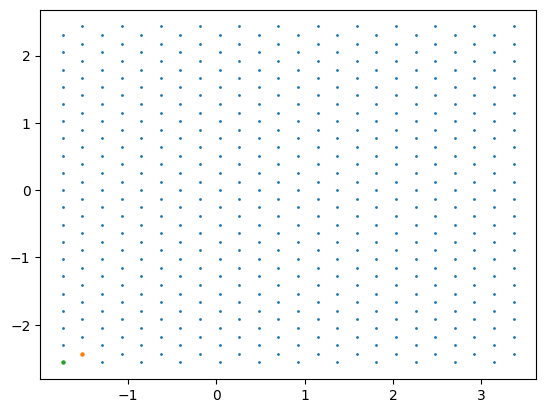

In [358]:
x,y=add_lattice(0.256,size=5)
plt.scatter(x,y,s=1)
#plt.xlim(-2.5,2.5)
#plt.ylim(-2.5,2.5)
i=240
plt.scatter(x[i],y[i],s=5)
plt.scatter(x[0],y[0],s=5)
points=np.array([[x[i],y[i]] for i in range(np.size(x))])

v=points[240]-points[0]


In [369]:
g[0]

array([-28.22990825,   0.        ])

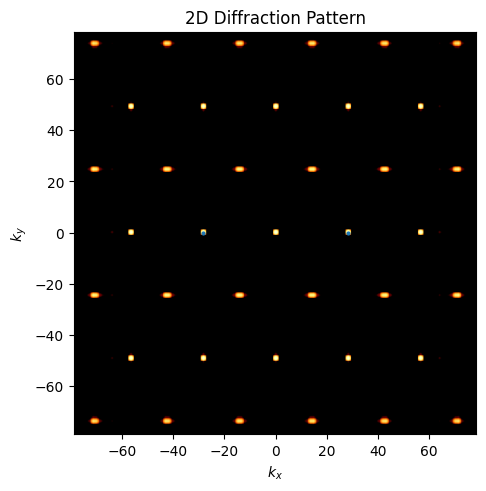

In [368]:
g=find_recip_vector(x,y,1,tolerance=1)

In [371]:
np.dot(g[0],v)/np.pi

-1.9921874090754532

In [372]:
2/1.9921874090754532

1.0039216144469925

In [12]:
import freud

In [420]:
x.shape

(480,)

In [422]:
np.random.uniform(0.99,1.01,480).shape

(480,)

In [426]:
def find_recip_vector(x,y,radius,tolerance=100,grid_size=512,lower=0.01,upper=1):
    points=np.array([[x[i],y[i],0] for i in range(np.size(x))])
    points=points-points[1]
    box3d = freud.Box.cube(L=np.abs(np.max(x)-np.min(x)))
    ssf =  freud.diffraction.DiffractionPattern(grid_size=grid_size)
    ssf.compute(system=(box3d, points))
    ssfmin, ssfmax = np.min(ssf.k_values), np.max(ssf.k_values)

    data=ssf.diffraction
# Define the center coordinates
    center_x = data.shape[0] // 2
    center_y = data.shape[1] // 2

# Define the radius of the center circle
    center_radius = radius/ssfmax*(grid_size/2)  # Adjust this value as needed

# Create a grid of distances from the center
    x, y = np.ogrid[:data.shape[0], :data.shape[1]]
    distances = np.sqrt((x - center_x)**2 + (y - center_y)**2)

# Create a circular mask to exclude the center region
    mask = distances <= center_radius

# Apply the mask to the array and find the maximum value
    max_value = np.max(data[~mask])
    peaks=(np.argwhere(np.abs(data-max_value)<tolerance)-(center_y,center_x))*ssfmax/(grid_size/2)
    peaks=peaks[:,::-1]
    peaks=peaks[np.sqrt((peaks[:,0]**2+peaks[:,1]**2))>radius]
    extent=[ssfmin, ssfmax, ssfmin, ssfmax]
    ssf_vals=ssf.to_image(cmap='afmhot',vmin=lower*ssf.N_points,vmax=upper*ssf.N_points)
    
    fig, ax = plt.subplots(1, 1, facecolor='w', constrained_layout=True,)
    sfax = ax.imshow(ssf_vals, origin='lower', cmap='afmhot', extent=[ssfmin, ssfmax, ssfmin, ssfmax])
    ax.set(xlabel=r'$k_{x}$', ylabel=r'$k_{y}$', title=r'2D Diffraction Pattern')
    ax.scatter(peaks[:,0],peaks[:,1],s=15)
    return peaks

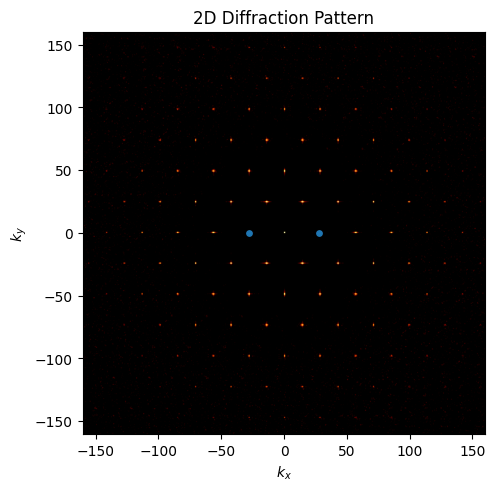

In [702]:
g=find_recip_vector(x1,y1,1,tolerance=1,grid_size=2048,lower=1e-3)

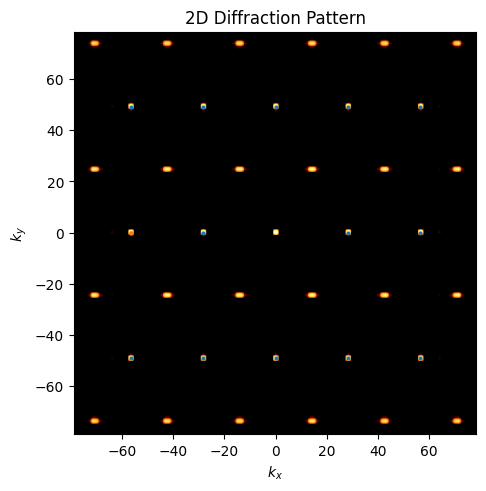

In [287]:
g=find_recip_vector(x,y,0.1,tolerance=100,)

In [276]:
def plot_tocf(x,y,g, bins=100,realdim=False, fit_id=None,
 p_dist=1,dpi=72,savename=False,filetype='svg',xtype='log',
               ytype='log',start=1,r2fit=1):
    points=np.array([[x[i],y[i]] for i in range(np.size(x))])
    points=points-points[1]
    rmax=np.abs(np.max(x)-np.min(x))

    bin_size=rmax/bins
    n = points.shape[0]
    pairwise_distances = []
    pairs = []
    
    for (i, j) in itertools.combinations(range(n), 2):
        dist = np.linalg.norm(points[i] - points[j])
        pairwise_distances.append(dist)
        pairs.append((i, j))   
    bins = defaultdict(list)    
    for dist, pair in zip(pairwise_distances, pairs):
        if dist <= rmax:
            bin_index = math.ceil(dist / bin_size)
            bins[bin_index].append(pair)
    torders=[]
    rs=[]
    for bin_index in sorted(bins.keys()):
        r=bin_index*bin_size-bin_size/2
        rs.append(r)
        prefactor=1/(2*np.pi*bin_size)
        terms=[]
        for pair in bins[bin_index]:
            terms.append(np.exp(1j*np.dot(g,points[pair[0]]-points[pair[1]])))
        torders.append(prefactor*np.array(terms).sum()/len(terms)) 
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', constrained_layout=True, dpi=dpi)
    rs=np.array(rs)
    torders=np.real(torders)
    ax.plot(rs, torders, 'o', ms=8, c='w', mec='b', zorder=2)
    ax.plot(rs, torders, lw=2.5, c='b', zorder=3)
    cfpks = find_peaks(torders,distance=p_dist,height=1e-10)[0]
    idxlim = np.argwhere(rs == rs[cfpks][start])[0][0]-1
    ax.plot(rs[cfpks[start:]], torders[cfpks[start:]], 'x', c='r', ms=14)
    
    fit_func, popt, fit_text = get_cffits(
        rs[cfpks[start:]],
        torders[cfpks[start:]], fit_id,r2fit=r2fit,)
    ax.plot(rs[idxlim:],np.exp(fit_func(rs[idxlim:], *popt)), '--', lw=1.5, c='k', zorder=9)
    #ax.plot(rs,np.exp(fit_func(rs), *popt), '--', lw=1.5, c='k', zorder=9)

    ax.set(xlabel=r'$r$', ylabel=f'$g_{{q}}(r)$', title=f'Translational Correlation Function $g_{{q}}(r)$  |  {fit_text}')
    ax.set_title(label=f'Translational Correlation Function $g_{{q}}(r)$  |  {fit_text}',
                fontsize=20)
    ax.set(xscale=xtype)
    ax.set(yscale=ytype)
    if savename!=False:
        fig.savefig(savename, format=filetype)

In [26]:
import itertools
from collections import defaultdict
import math

In [283]:
2/1.9921874090754532

1.0039216144469925

popt_constfunc (r2=1, rmse=0.010711): [0.17428513]
popt_pwrlawdecay (r2=0.0015573, rmse=0.00042268): [1.30369332 0.50030157]
popt_expdecay (r2=0.0021724, rmse=0.00049922): [ 0.67327776 19.16044413]

winner: power law fit



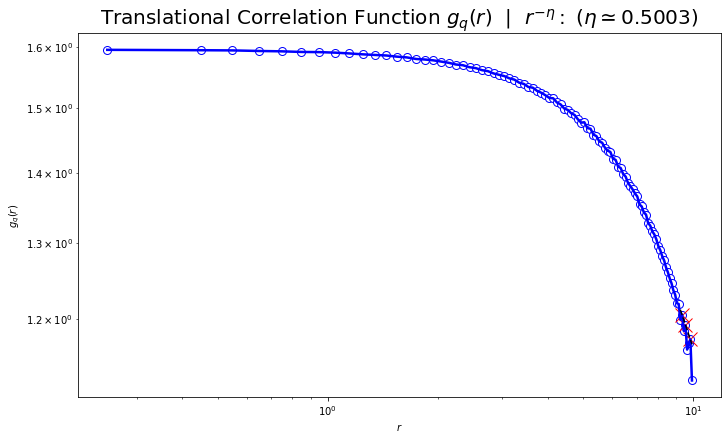

In [34]:
plot_tocf(x,y,g,)

In [692]:
def plot_bocf(x,y, bins=100, fit_id=None,dist=6, dpi=72,savename=False,
filetype='svg',realdim=False,start=7,xtype='log',ytype='log',r2fit=1,figsize_=(10,6)):
    """
    Plots the bond-orientational correlation function as a function of distance.
    """
#     sigma = np.sqrt(2. / ((3.**0.5) * sim.rho))
    points=np.array([[x[i],y[i],0] for i in range(np.size(x))])
    points=points-points[1]
    rmax=np.abs(np.max(x)-np.min(x))
    box = freud.box.Box(Lx=rmax*5, Ly=rmax*5, Lz=0, is2D=True) 
    #Freud uses periodic boundaries, so making boundaries far and only calculating close
    fpsi = freud.order.Hexatic(k=6, weighted=False)
    cf = freud.density.CorrelationFunction(bins=bins, r_max=rmax*0.5)
    fpsi.compute(system=(box, points))
    fpsi_complex = fpsi.particle_order
    cf.compute(system=(box, points), values=fpsi_complex)    
    cf_edges = cf.bin_edges[:-1] #/ sigma
    cf_vals=np.real(cf.correlation)
    
    fig, ax = plt.subplots(figsize=figsize_, facecolor='w', constrained_layout=True, dpi=dpi)
    
    ax.plot(cf_edges, cf_vals, 'o', ms=8, c='w', mec='b', zorder=2)
    ax.plot(cf_edges, cf_vals, lw=2.5, c='b', zorder=3) 
    
    cfpks = find_peaks(cf_vals, distance=dist,height=1e-10)[0]
    ax.set(xlim=(cf_edges[cfpks[0]]*0.75, cf_edges[-1]*1.1))
    ax.set_ylim(top=2,bottom=1e-5)
    idxlim = np.argwhere(cf_edges == cf_edges[cfpks][start])[0][0]-1
    ax.plot(cf_edges[cfpks[start:]],cf_vals[cfpks[start:]], 'x', c='r', ms=14)
    
    fit_func, popt, fit_text = get_cffits(cf_edges[cfpks[start:]], cf_vals[cfpks[start:]], fit_id,r2fit=r2fit)
    ax.plot(cf_edges[idxlim:],np.exp( fit_func(np.log(cf_edges[idxlim:]), *popt)), '--', lw=2., c='k', zorder=9)
    
    ax.set(xlabel=r'$r$', ylabel=f'$g_{{6}}(r)$', title=f'Bond-orientational Correlation Function $g_{{6}}(r)$  |  {fit_text}')
    ax.set_title(
        label=f'Bond-orientational Correlation Function $g_{{6}}(r)$  |  {fit_text}',
        fontsize=20)

    ax.set(xscale=xtype)
    ax.set(yscale=ytype)
    if savename!=False:
        fig.savefig(savename, format=filetype)
    return fpsi_complex

In [100]:
np.dot([5,1,3],np.array([5,2,7]).T)

48

In [640]:
def plot_tocf(x,y,g, bins=100, fit_id=None,dist=6, dpi=72,savename=False,
filetype='svg',realdim=False,start=7,xtype='log',ytype='log',r2fit=1,figsize_=(10,6)):
    """
    Plots the bond-orientational correlation function as a function of distance.
    """
    g=np.array([g[0],g[1],0])
#     sigma = np.sqrt(2. / ((3.**0.5) * sim.rho))
    points=np.array([[x[i],y[i],0] for i in range(np.size(x))])
    points=points-points[1]
    rmax=np.abs(np.max(x)-np.min(x))
    box = freud.box.Box(Lx=rmax*5, Ly=rmax*5, Lz=0, is2D=True) 
    #Freud uses periodic boundaries, so making boundaries far and only calculating close
    #fpsi = freud.order.Hexatic(k=6, weighted=False)
    cf = freud.density.CorrelationFunction(bins=bins, r_max=rmax)
    #fpsi.compute(system=(box, points))
    #fpsi_complex = fpsi.particle_order
    fpsi_complex=np.exp(1j*np.dot(g,points.T))
    cf.compute(system=(box, points), values=fpsi_complex)    
    cf_edges = cf.bin_edges[:-1] #/ sigma
    cf_vals=np.real(cf.correlation)
    cfpks = find_peaks(cf_vals, distance=dist,height=1e-100)[0]

    fig, ax = plt.subplots(figsize=figsize_, facecolor='w', constrained_layout=True, dpi=dpi)
    ax.set(xlim=(cf_edges[cfpks[0]]*0.75, cf_edges[-1]*1.1))
    #ax.set_ylim(np.min(cf_vals[cf_vals>0]),np.max(cf_vals[cf_vals>0])*1.1)
    ax.set_ylim(top=2,bottom=1e-5)
    ax.set(xscale=xtype)
    ax.set(yscale=ytype)
    ax.plot(cf_edges, cf_vals, 'o', ms=8, c='w', mec='b', zorder=2)
    ax.plot(cf_edges, cf_vals, lw=2.5, c='b', zorder=3) 
    
    
    idxlim = np.argwhere(cf_edges == cf_edges[cfpks][start])[0][0]-1
    ax.plot(cf_edges[cfpks[start:]],cf_vals[cfpks[start:]], 'x', c='r', ms=14)
    
    fit_func, popt, fit_text = get_cffits(cf_edges[cfpks[start:]], cf_vals[cfpks[start:]], fit_id,r2fit=r2fit)
    ax.plot((cf_edges[idxlim:]),np.exp( fit_func(np.log(cf_edges[idxlim:]), *popt)), '--', lw=2., c='k', zorder=9)
    
    ax.set(xlabel=r'$r$', ylabel=f'$g_{{6}}(r)$', title=f'Bond-orientational Correlation Function $g_{{6}}(r)$  |  {fit_text}')
    ax.set_title(
        label=f'Bond-orientational Correlation Function $g_{{6}}(r)$  |  {fit_text}',
        fontsize=20)

    if savename!=False:
        fig.savefig(savename, format=filetype)

In [302]:
np.exp(1)

2.718281828459045

In [ ]:
pl

In [350]:
np.dot(g[0],np.array([[x[i],y[i]] for i in range(np.size(x))]).T)/(2*np.pi)


array([ 35.58775575,  31.60338093,  27.61900611,  23.63463129,
        19.65025647,  15.66588166,  11.68150684,   7.69713202,
         3.7127572 ,  -0.27161762,  -4.25599243,  -8.24036725,
        33.58742542,  29.6030506 ,  25.61867579,  21.63430097,
        17.64992615,  13.66555133,   9.68117651,   5.69680169,
         1.71242688,  -2.27194794,  -6.25632276, -10.24069758,
        31.5870951 ,  27.60272028,  23.61834546,  19.63397064,
        15.64959582,  11.66522101,   7.68084619,   3.69647137,
        -0.28790345,  -4.27227827,  -8.25665308, -12.2410279 ,
        29.58676477,  25.60238995,  21.61801514,  17.63364032,
        13.6492655 ,   9.66489068,   5.68051586,   1.69614104,
        -2.28823377,  -6.27260859, -10.25698341, -14.24135823,
        27.58643445,  23.60205963,  19.61768481,  15.63330999,
        11.64893517,   7.66456036,   3.68018554,  -0.30418928,
        -4.2885641 ,  -8.27293892, -12.25731373, -16.24168855,
        25.58610412,  21.6017293 ,  17.61735449,  13.63

In [ ]:
2*np.pi

In [625]:
g

array([-28.28526119,   0.        ])

(24,)

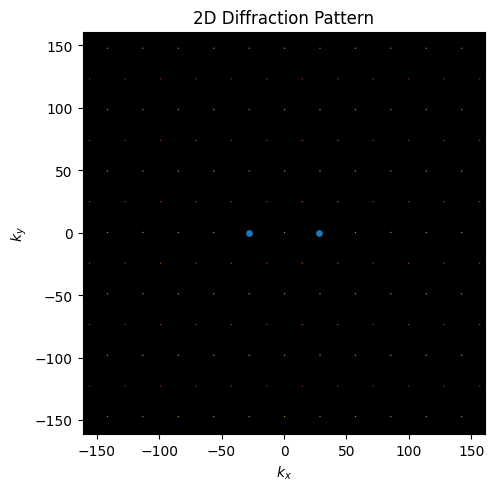

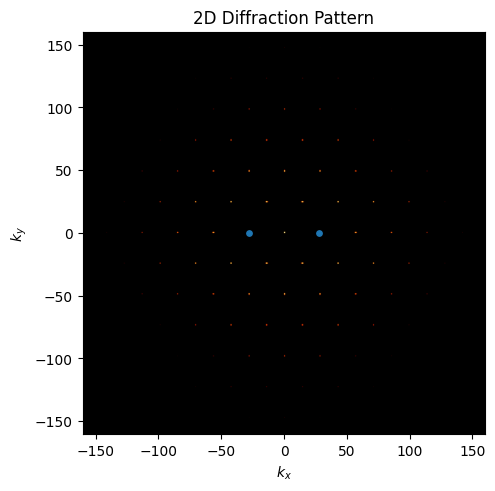

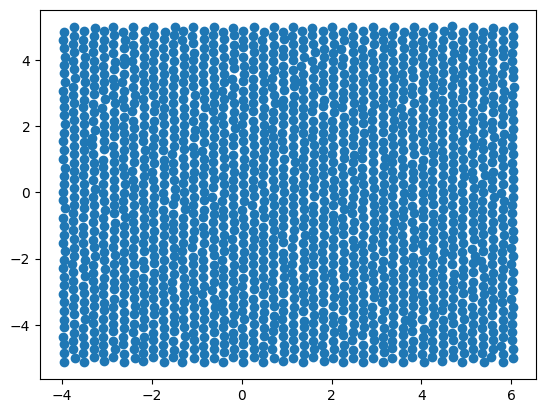

In [684]:
x,y=add_lattice(0.256,size=10)
g=find_recip_vector(x,y,1,tolerance=0.001,grid_size=2048,lower=1e-1)[0]
dist=x[0]-x[1]
i=int(x.shape[0]/2)
x1=x+np.random.normal(0,0.03,x.shape[0])*dist
y1=y+np.random.normal(0,0.03,x.shape[0])*dist
g1=find_recip_vector(x1,y1,2,tolerance=0.001,grid_size=2048,lower=0.01)[0]
v=np.array((x[i],y[i]))-np.array((x[0],y[0]))
v1=np.array((x1[i],y1[i]))-np.array((x[0],y[0]))

plt.figure()
plt.scatter(x1,y1)

In [599]:
g

array([-3.81823602,  0.        ])

In [661]:
2*np.pi/np.dot(g,v)


-1.0009775206697706

In [664]:
2*np.pi/np.dot(g1,v1)

-0.9298551995801413

popt_constfunc (r2=1, rmse=9.1518e-05): [-0.00012654]
popt_pwrlawdecay (r2=0.23629, rmse=4.4487e-05): [-0.00022062  0.00020154]
popt_expdecay (r2=0.10083, rmse=2.9061e-05): [1.12618171e-04 2.85055936e+03]

winner: exponential fit

popt_constfunc (r2=1, rmse=0.32772): [-0.32692479]
popt_pwrlawdecay (r2=0.96367, rmse=0.32171): [-0.39485308  0.12743298]
popt_expdecay (r2=0.9735, rmse=0.32335): [-0.19819299  5.06593242]

winner: power law fit



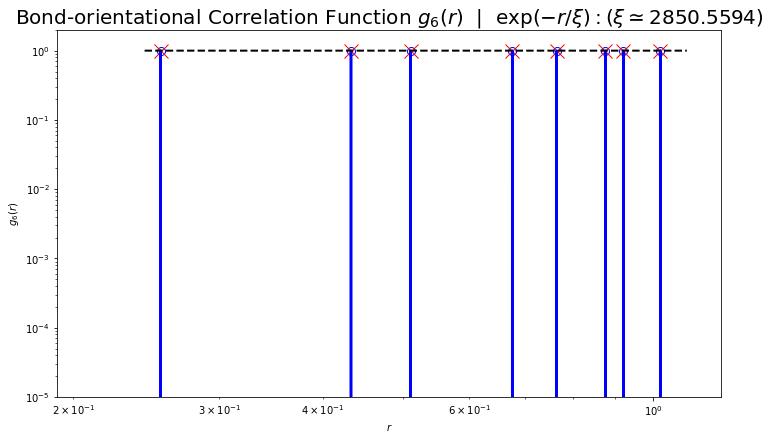

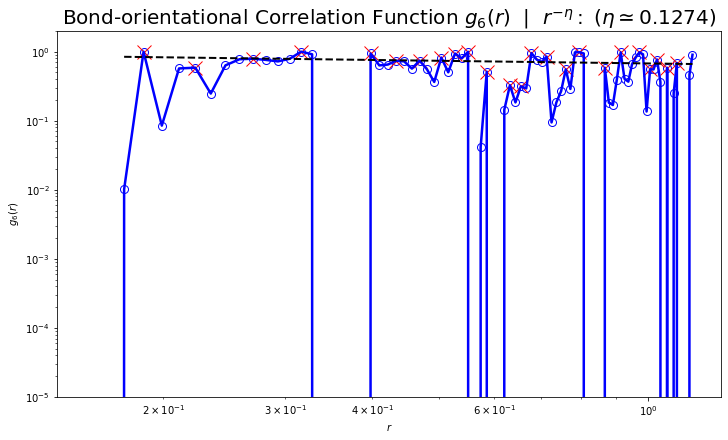

In [665]:
plot_tocf(x,y,g,xtype='log',ytype='log',fit_id=None,start=0,dist=1)
plot_tocf(x1,y1,g1,xtype='log',ytype='log',fit_id=None,start=0,dist=1)

popt_constfunc (r2=1, rmse=0.0078768): [-0.00929889]
popt_pwrlawdecay (r2=0.19669, rmse=0.0034934): [-0.00503839  0.00438222]
popt_expdecay (r2=0.035206, rmse=0.0014779): [1.34290854e-03 5.34370975e+02]

winner: exponential fit

popt_constfunc (r2=1, rmse=0.68783): [-0.95757487]
popt_pwrlawdecay (r2=0.52338, rmse=0.49761): [-0.28568292  0.53701072]
popt_expdecay (r2=0.20945, rmse=0.31479): [0.11809286 4.26390045]

winner: exponential fit



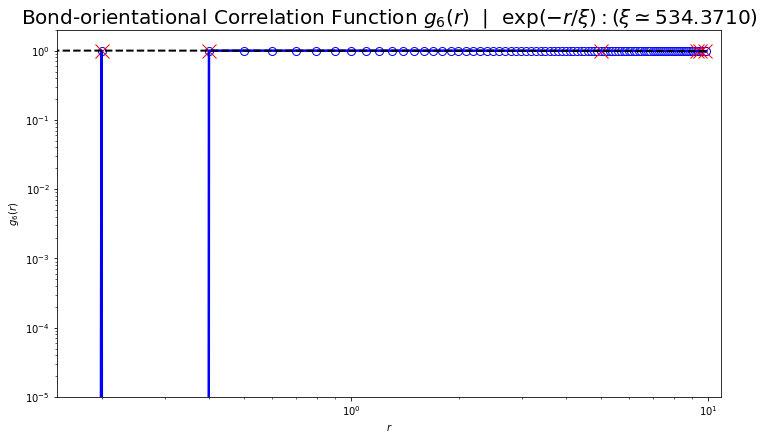

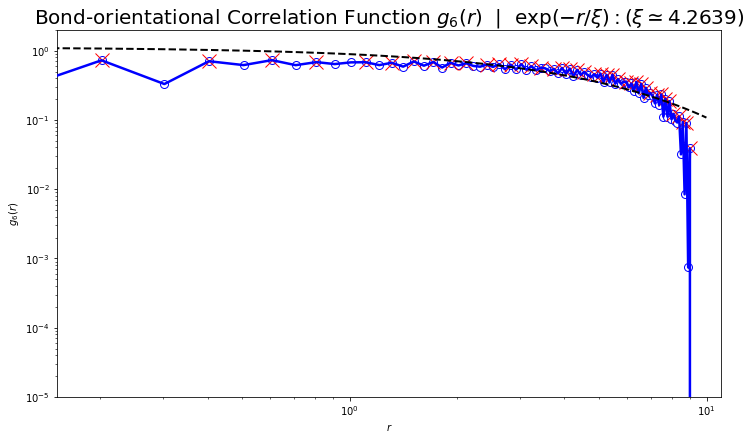

In [667]:
plot_tocf(x,y,g,xtype='log',ytype='log',fit_id=None,start=0,dist=1)
plot_tocf(x1,y1,g1,xtype='log',ytype='log',fit_id=None,start=0,dist=1)

popt_constfunc (r2=1, rmse=0.0078768): [-0.00929889]
popt_pwrlawdecay (r2=0.19669, rmse=0.0034934): [-0.00503839  0.00438222]
popt_expdecay (r2=0.035206, rmse=0.0014779): [1.34290854e-03 5.34370975e+02]

winner: exponential fit

popt_constfunc (r2=1, rmse=0.036748): [-0.05581809]
popt_pwrlawdecay (r2=0.36989, rmse=0.02235): [-0.01408358  0.03211441]
popt_expdecay (r2=0.064255, rmse=0.0093151): [6.25994887e-03 7.84341195e+01]

winner: exponential fit



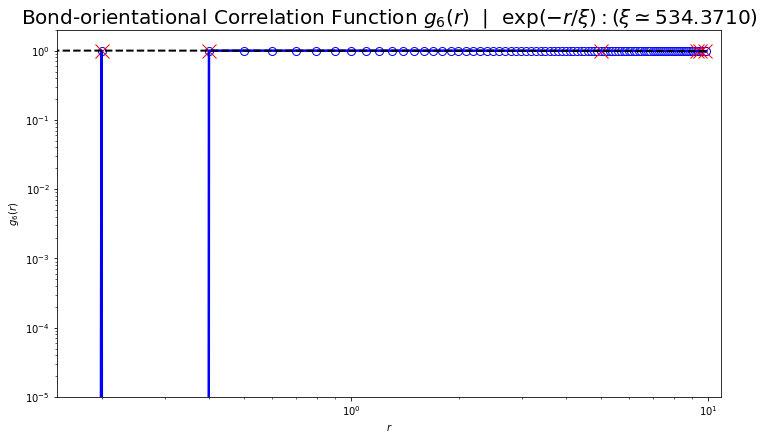

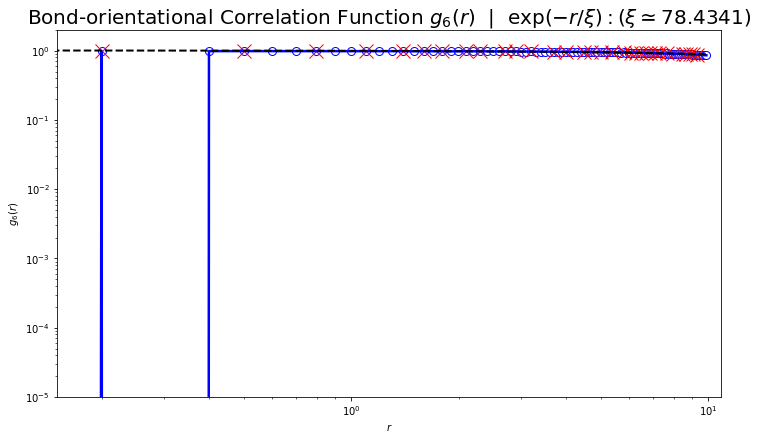

In [669]:
plot_tocf(x,y,g,xtype='log',ytype='log',fit_id=None,start=0,dist=1)
plot_tocf(x1,y1,g1,xtype='log',ytype='log',fit_id=None,start=0,dist=1)

popt_constfunc (r2=1, rmse=0.0082813): [-0.07673027]
popt_pwrlawdecay (r2=0.27324, rmse=0.0043288): [-0.07092373  0.00908452]
popt_expdecay (r2=0.048553, rmse=0.0018248): [-6.25152635e-02  1.68791752e+02]

winner: exponential fit

popt_constfunc (r2=1, rmse=0.01184): [-0.27152812]
popt_pwrlawdecay (r2=0.29639, rmse=0.0064458): [-0.26187087  0.01332514]
popt_expdecay (r2=0.096132, rmse=0.003671): [ -0.25066056 122.64644728]

winner: exponential fit



array([-0.3250935 +0.06734008j,  0.01266918-0.00190042j,
       -0.00152701+0.00454715j, ...,  0.02253673-0.03972688j,
        0.00890465-0.10938356j, -0.31871182+0.14318138j], dtype=complex64)

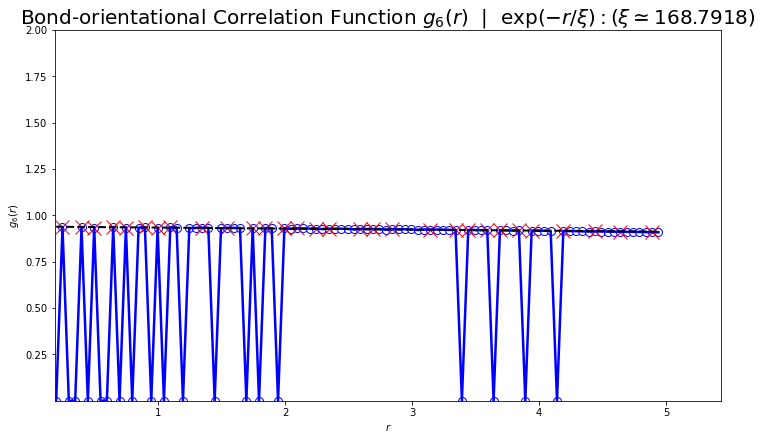

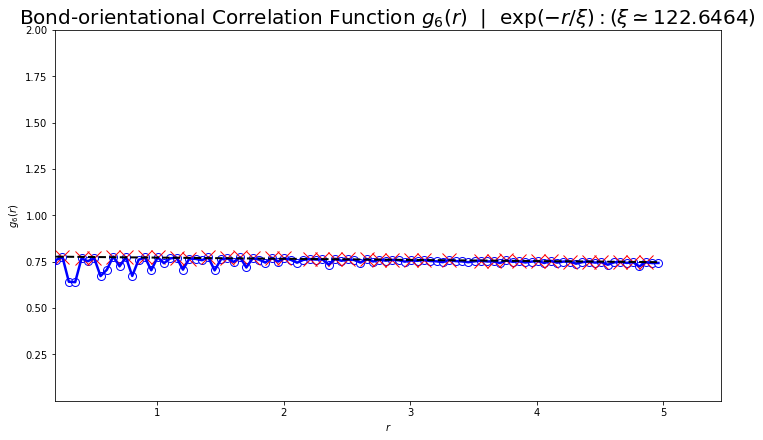

In [693]:
plot_bocf(x,y,xtype='linear',ytype='linear',fit_id=None,start=0,dist=1)
plot_bocf(x1,y1,xtype='linear',ytype='linear',fit_id=None,start=0,dist=1)
